In [14]:
import pandas as pd
import numpy as np

# Load data
train = pd.read_csv('train_data_1pct.csv')
labels = pd.read_csv('train_labels_1pct.csv')

print("Train data shape:", train.shape)
print("Labels shape:", labels.shape)
print("Unique customers in train:", train['customer_ID'].nunique())
print("Default rate:", labels['target'].mean())

# S_2 is the statement date - convert it
train['S_2'] = pd.to_datetime(train['S_2'])

# Aggregate time-series data per customer: mean, std, min, max, last value
# This is the feature engineering step that differentiates a good project from a lazy one
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()

agg_funcs = ['mean', 'std', 'min', 'max', 'last']
customer_features = train.groupby('customer_ID')[num_cols].agg(agg_funcs)
customer_features.columns = ['_'.join(col) for col in customer_features.columns]
customer_features = customer_features.reset_index()

# Merge with labels
final_df = customer_features.merge(labels, on='customer_ID', how='inner')

print("\nFinal modeling dataset shape:", final_df.shape)
print("Missing values per column (top 10):")
print(final_df.isnull().sum().sort_values(ascending=False).head(10))

final_df.to_csv('amex_processed.csv', index=False)

Train data shape: (55249, 190)
Labels shape: (4589, 2)
Unique customers in train: 4589
Default rate: 0.24624101111353236

Final modeling dataset shape: (4589, 932)
Missing values per column (top 10):
D_87_std     4586
D_87_max     4583
D_87_mean    4583
D_87_min     4583
D_87_last    4583
D_88_std     4574
D_88_min     4571
D_88_mean    4571
D_88_max     4571
D_88_last    4571
dtype: int64


In [15]:
data_ids = set(train['customer_ID'].unique())
label_ids = set(labels['customer_ID'].unique())
print("Data customers:", len(data_ids))
print("Label customers:", len(label_ids))
print("Overlap:", len(data_ids & label_ids))

Data customers: 4589
Label customers: 4589
Overlap: 4589


In [16]:
# Drop columns with too much missing data (D_87, D_88 etc.)
missing_pct = final_df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.5].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >50% missing:", cols_to_drop[:10], "...")

final_df_clean = final_df.drop(columns=cols_to_drop)

# For remaining missing values, fill with median (simple, defensible approach)
from sklearn.impute import SimpleImputer

feature_cols = [c for c in final_df_clean.columns if c not in ['customer_ID', 'target']]
imputer = SimpleImputer(strategy='median')
final_df_clean[feature_cols] = imputer.fit_transform(final_df_clean[feature_cols])

print("Final clean shape:", final_df_clean.shape)
print("Any remaining nulls?", final_df_clean.isnull().sum().sum())

final_df_clean.to_csv('amex_clean.csv', index=False)

Dropping 130 columns with >50% missing: ['D_42_mean', 'D_42_std', 'D_42_min', 'D_42_max', 'D_42_last', 'D_49_mean', 'D_49_std', 'D_49_min', 'D_49_max', 'D_49_last'] ...
Final clean shape: (4589, 802)
Any remaining nulls? 0


In [17]:
# Instead of 5 aggregations per column, pick 2 that matter most for time-series risk data
# 'last' = most recent customer state (most predictive for near-term default)
# 'mean' = overall behavioral trend
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
agg_funcs = ['mean', 'last']  # down from 5 to 2

customer_features = train.groupby('customer_ID')[num_cols].agg(agg_funcs)
customer_features.columns = ['_'.join(col) for col in customer_features.columns]
customer_features = customer_features.reset_index()

In [18]:
from sklearn.feature_selection import SelectKBest, f_classif

final_df_clean = final_df_clean.dropna(axis=0)  # safety check
feature_cols = [c for c in final_df_clean.columns if c not in ['customer_ID', 'target']]

X = final_df_clean[feature_cols]
y = final_df_clean['target']

selector = SelectKBest(score_func=f_classif, k=60)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()].tolist()

print("Selected features:", selected_features[:15], "...")
print("New shape:", X_selected.shape)

Selected features: ['P_2_mean', 'P_2_min', 'P_2_max', 'P_2_last', 'B_2_mean', 'B_2_min', 'B_2_last', 'R_1_mean', 'R_1_std', 'R_1_max', 'R_1_last', 'B_3_std', 'B_3_max', 'B_3_last', 'D_44_mean'] ...
New shape: (4589, 60)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [483] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for train_idx, val_idx in skf.split(X_selected, y):
    X_train, X_val = X_selected[train_idx], X_selected[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds)
    auc_scores.append(auc)

print(f"5-Fold CV AUC (60 features): {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

5-Fold CV AUC (60 features): 0.9382 ± 0.0071


In [20]:
# Instead of 5 aggregations per column, pick 2 that matter most for time-series risk data
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
agg_funcs = ['mean', 'last']
customer_features = train.groupby('customer_ID')[num_cols].agg(agg_funcs)
customer_features.columns = ['_'.join(col) for col in customer_features.columns]
customer_features = customer_features.reset_index()

In [21]:
import shap
import matplotlib.pyplot as plt

# Train one final model on ALL selected features (not just one fold) for SHAP analysis
final_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
final_model.fit(X_selected, y)

# TreeExplainer is fast and exact for tree-based models like RandomForest
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_selected)

# For binary classification, shap_values is a list [class_0, class_1] — we want class 1 (default)
shap_vals_default = shap_values[1] if isinstance(shap_values, list) else shap_values

shap_values = explainer.shap_values(X_selected)

# Handle both old (list) and new (3D array) SHAP API
if isinstance(shap_values, list):
    shap_vals_default = shap_values[1]           # old API: list of arrays per class
elif shap_values.ndim == 3:
    shap_vals_default = shap_values[:, :, 1]      # new API: (samples, features, classes)
else:
    shap_vals_default = shap_values               # already 2D

print("SHAP values shape:", shap_vals_default.shape)  # sanity check: should be (n_customers, 60)

SHAP values shape: (4589, 60)


In [22]:
print(final_df.shape)
print(final_df_clean.shape)
print(X_selected.shape)
print(train['customer_ID'].nunique())

(4589, 932)
(4589, 802)
(4589, 60)
4589


In [23]:
!ls -la *.csv
!wc -l train_data_1pct.csv train_labels_1pct.csv

-rw-r--r-- 1 root root  69346603 Jul 17 13:56 amex_clean.csv
-rw-r--r-- 1 root root  69480368 Jul 17 13:56 amex_processed.csv
-rw-r--r-- 1 root root 163737175 Jul 17 13:40 train_data_1pct.csv
-rw-r--r-- 1 root root    307482 Jul 17 13:36 train_labels_1pct.csv
    55250 train_data_1pct.csv
     4590 train_labels_1pct.csv
    59840 total


In [24]:
print(train.shape)
print(train['customer_ID'].nunique())

(55249, 190)
4589


In [26]:
import mapie
print(mapie.__version__)

import mapie.classification as mc
print([x for x in dir(mc) if not x.startswith('_')])

1.4.1
['Any', 'ArrayLike', 'BaseClassificationScore', 'BaseCrossValidator', 'BaseEstimator', 'BaseShuffleSplit', 'ClassifierMixin', 'CrossConformalClassifier', 'EnsembleClassifier', 'Iterable', 'LabelEncoder', 'Literal', 'LogisticRegression', 'NDArray', 'Optional', 'RAPSConformityScore', 'SplitConformalClassifier', 'Tuple', 'Union', 'annotations', 'cast', 'check_and_select_conformity_score', 'check_classification_conformity_score', 'check_is_fitted', 'check_proba_normalized', 'check_random_state', 'check_target', 'clone', 'indexable', 'np', 'warnings']


In [29]:
print("y_pred_set shape:", y_pred_set.shape)  # sanity check, should be (918, 2, 1)

pred_set_size = y_pred_set.sum(axis=1).ravel()  # .ravel() flattens (918,1) -> (918,)

print("\nConformal prediction @ 90% confidence")
print("Distribution of prediction set sizes:")
print(pd.Series(pred_set_size).value_counts())

confident_mask = pred_set_size == 1
uncertain_mask = pred_set_size >= 2

print(f"\nConfident predictions: {confident_mask.sum()} ({confident_mask.mean()*100:.1f}%)")
print(f"Uncertain predictions (flag for review): {uncertain_mask.sum()} ({uncertain_mask.mean()*100:.1f}%)")

acc_confident = accuracy_score(np.array(y_test)[confident_mask], np.array(y_pred)[confident_mask]) if confident_mask.sum() > 0 else None
acc_overall = accuracy_score(y_test, y_pred)
print(f"\nAccuracy on confident subset: {acc_confident}")
print(f"Overall accuracy: {acc_overall:.4f}")

proba_test = base_model.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, proba_test)
print(f"Test AUC (held-out): {auc_test:.4f}")

results_df = pd.DataFrame({
    'true_label': np.array(y_test),
    'predicted_proba': proba_test,
    'predicted_class': y_pred,
    'prediction_set_size': pred_set_size,
    'confident': confident_mask
})
results_df.to_csv('conformal_results.csv', index=False)
print("\nSaved conformal_results.csv")

y_pred_set shape: (918, 2, 1)

Conformal prediction @ 90% confidence
Distribution of prediction set sizes:
1    911
2      7
Name: count, dtype: int64

Confident predictions: 911 (99.2%)
Uncertain predictions (flag for review): 7 (0.8%)

Accuracy on confident subset: 0.8803512623490669
Overall accuracy: 0.8758
Test AUC (held-out): 0.9424

Saved conformal_results.csv


In [33]:
import pandas as pd
import numpy as np

# Re-do the split but keep track of original row indices, so we can trace back to customer_ID / raw balances
indices = np.arange(len(final_df_clean))
idx_train, idx_temp = train_test_split(indices, test_size=0.4, random_state=42, stratify=y)
idx_calib, idx_test = train_test_split(idx_temp, test_size=0.5, random_state=42, stratify=y.iloc[idx_temp])

# Sanity check: these should match X_train/X_calib/X_test shapes you already have
print(len(idx_train), len(idx_calib), len(idx_test))

# Pull customer_ID + a real exposure column from the ORIGINAL final_df_clean (before feature selection)
test_customers = final_df_clean.iloc[idx_test]['customer_ID'].values

# EAD proxy: use a balance-type column. B_1_last = most recent balance snapshot is a reasonable EAD proxy.
# Check it exists first:
ead_col = 'B_1_last' if 'B_1_last' in final_df_clean.columns else [c for c in final_df_clean.columns if c.startswith('B_1_')][0]
print("Using EAD proxy column:", ead_col)

ead_raw = final_df_clean.iloc[idx_test][ead_col].values
# These balance columns are normalized/scaled in AMEX-style data (0-1ish), so scale to a nominal exposure amount
# Assume max credit exposure of $25,000 as a reasonable unsecured personal-credit ceiling for this proxy
EAD = ead_raw * 25000
EAD = np.clip(EAD, 0, None)  # no negative exposure

# PD comes straight from your trained model
PD = base_model.predict_proba(X_test)[:, 1]

# LGD: Basel II standard for unsecured retail/consumer credit
LGD = 0.45

# Expected Loss per customer
EL = PD * LGD * EAD
print("test_customers:", test_customers.shape if hasattr(test_customers, 'shape') else len(test_customers))
print("PD:", PD.shape)
print("LGD:", type(LGD))  # should just be a scalar float
print("EAD:", EAD.shape)
print("expected_loss (EL):", EL.shape)
print("pred_set_size:", pred_set_size.shape)
pred_set_size = np.asarray(pred_set_size).ravel()  # (918,1) -> (918,)
print("pred_set_size fixed:", pred_set_size.shape)
risk_df = pd.DataFrame({
    'customer_ID': test_customers,
    'PD': PD,
    'LGD': LGD,
    'EAD': EAD,
    'expected_loss': EL,
    'prediction_set_size': pred_set_size  # from your conformal step, same test set
})

print(risk_df.describe())
print("\nTotal portfolio expected loss:", risk_df['expected_loss'].sum())
risk_df.to_csv('risk_df.csv', index=False)
print("\nSaved risk_df.csv")
risk_df.head(10)

2753 918 918
Using EAD proxy column: B_1_last
test_customers: (918,)
PD: (918,)
LGD: <class 'float'>
EAD: (918,)
expected_loss (EL): (918,)
pred_set_size: (918, 1)
pred_set_size fixed: (918,)
               PD           LGD           EAD  expected_loss  \
count  918.000000  9.180000e+02    918.000000     918.000000   
mean     0.247560  4.500000e-01   3397.663148     760.052080   
std      0.298967  7.220383e-15   5520.821991    1618.169978   
min      0.008766  4.500000e-01      0.000000       0.000000   
25%      0.013691  4.500000e-01    224.784058       2.171619   
50%      0.077132  4.500000e-01    886.826574      24.116367   
75%      0.452129  4.500000e-01   3886.585211     751.445996   
max      0.976386  4.500000e-01  32981.675240   14313.946647   

       prediction_set_size  
count           918.000000  
mean              1.007625  
std               0.087037  
min               1.000000  
25%               1.000000  
50%               1.000000  
75%               1.000000  

,customer_ID,PD,LGD,EAD,expected_loss,prediction_set_size
0,b7fe7835eceb3f94d4375b7ee191244f88f14ab689a938...,0.738850,0.45,14267.274844,4743.619968,1
1,3ae5cf910f745920894c78016d592eb9ce145674c1ce96...,0.343031,0.45,207.477823,32.027061,1
2,aec678f9011ee7c4bfca00ba2d25de3c65db2e2789b819...,0.966610,0.45,32907.549040,14313.946647,1
3,ebf8e7c58ee19c6b36439415a72c6794f8d2d2a0cfcf0f...,0.681188,0.45,29799.188617,9134.485353,1
4,d328609655b8bef8ea7d91e069df20366bba3f9282ee97...,0.229341,0.45,12005.506851,1239.007781,1
5,a2b7963e5c0275502faefdcd19ac5beecd21c54063c7ad...,0.009104,0.45,198.739657,0.814232,1
6,3c79006fbcf923edf14780e18a0beaba5baf36b4257fe4...,0.372129,0.45,17151.801324,2872.205724,1
7,dd25da42fe784ed1584d51aab7d9b87dd6804aa459bf81...,0.019779,0.45,125.238825,1.114708,1
8,421f4d724aab66c1f2a10ed29cb6909fa5dcb86841ff6c...,0.651736,0.45,2549.087577,747.599616,1
9,102340415ce154ecc66636eb2c34319680a8b0a6ef12f2...,0.718350,0.45,2800.449394,905.266209,1


In [34]:
!pip install pulp -q
import pulp

n = len(risk_df)
prob = pulp.LpProblem("Capital_Allocation", pulp.LpMaximize)

approve = [pulp.LpVariable(f"approve_{i}", lowBound=0, upBound=1) for i in range(n)]

risk_adjusted_value = [
    approve[i] * (risk_df['EAD'].iloc[i] - risk_df['expected_loss'].iloc[i])
    for i in range(n)
]
prob += pulp.lpSum(risk_adjusted_value)

total_requested_EAD = risk_df['EAD'].sum()
capital_budget = 0.6 * total_requested_EAD
prob += pulp.lpSum([approve[i] * risk_df['EAD'].iloc[i] for i in range(n)]) <= capital_budget

max_allowed_EL = 0.02 * total_requested_EAD
prob += pulp.lpSum([approve[i] * risk_df['expected_loss'].iloc[i] for i in range(n)]) <= max_allowed_EL

prob.solve()

print("Solver status:", pulp.LpStatus[prob.status])

risk_df['approve_fraction'] = [pulp.value(a) for a in approve]
risk_df['approved_EAD'] = risk_df['approve_fraction'] * risk_df['EAD']
risk_df['approved_EL'] = risk_df['approve_fraction'] * risk_df['expected_loss']

print("\nTotal capital budget:", capital_budget)
print("Total EAD approved:", risk_df['approved_EAD'].sum())
print("Total EL under approved allocation:", risk_df['approved_EL'].sum())
print("Max allowed EL (risk appetite):", max_allowed_EL)
print("\nFraction fully approved (~1):", (risk_df['approve_fraction'] > 0.99).mean())
print("Fraction fully rejected (~0):", (risk_df['approve_fraction'] < 0.01).mean())

risk_df.to_csv('risk_df_optimized.csv', index=False)
print("\nSaved risk_df_optimized.csv")

Solver status: Optimal

Total capital budget: 1871432.8616731025
Total EAD approved: 970006.6064503251
Total EL under approved allocation: 62381.0953815999
Max allowed EL (risk appetite): 62381.095389103415

Fraction fully approved (~1): 0.6721132897603486
Fraction fully rejected (~0): 0.3235294117647059

Saved risk_df_optimized.csv


/tmp/ipykernel_524/3102714639.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


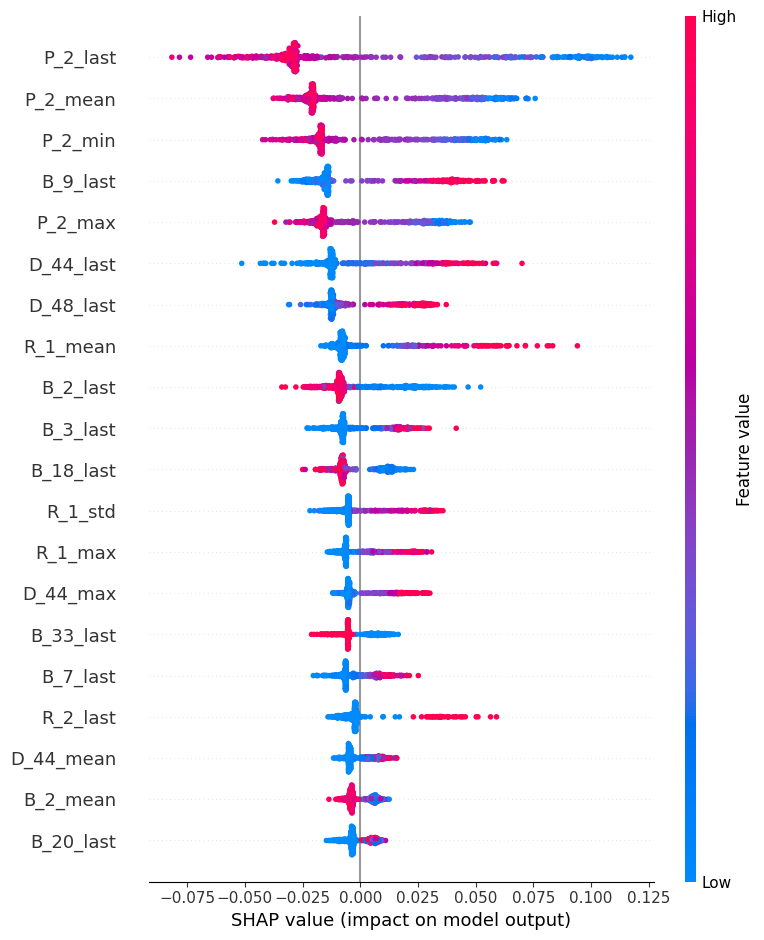

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# Subsample 500 rows for the beeswarm plot (rendering is O(n), full 4589 is slow)
np.random.seed(42)
sample_idx = np.random.choice(len(X_selected), size=500, replace=False)

plt.figure()
shap.summary_plot(
    shap_vals_default[sample_idx],
    X_selected[sample_idx],
    feature_names=selected_features,
    show=False
)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_524/2458783096.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


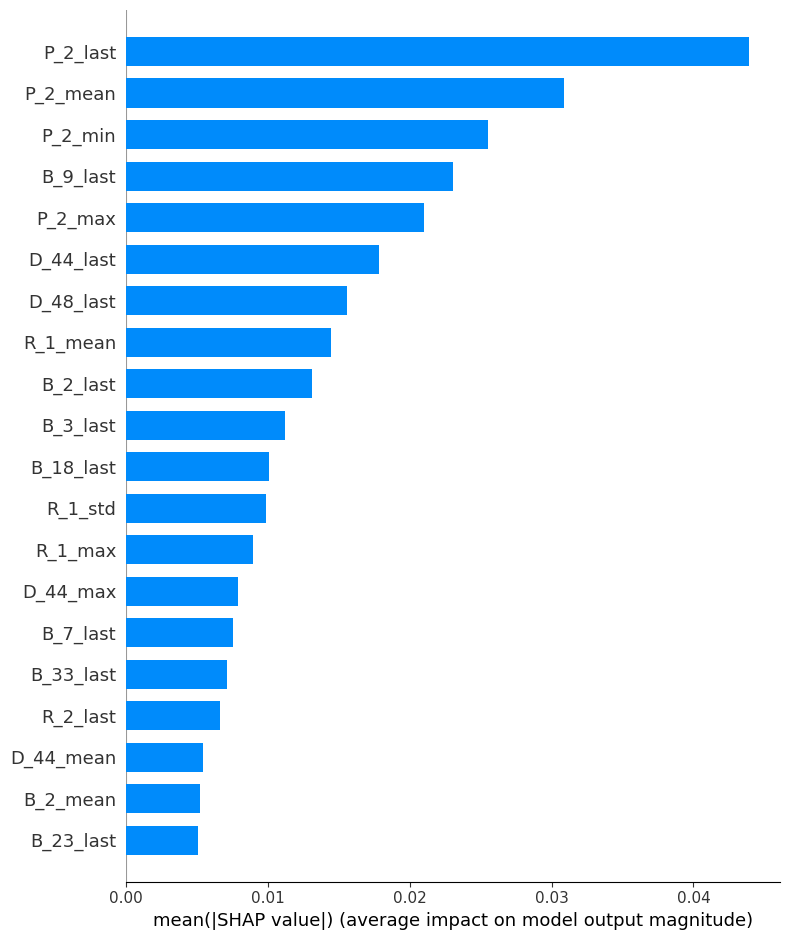

In [37]:
plt.figure()
shap.summary_plot(
    shap_vals_default, X_selected,
    feature_names=selected_features,
    plot_type='bar', show=False
)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

                     scenario  total_expected_loss   mean_PD  \
0                    Baseline        697727.809376  0.247560   
1    Mild Recession (+20% PD)        816614.284036  0.290823   
2  Severe Recession (+50% PD)        936868.967832  0.337440   

   pct_above_50pct_PD  
0           23.529412  
1           26.252723  
2           30.610022  


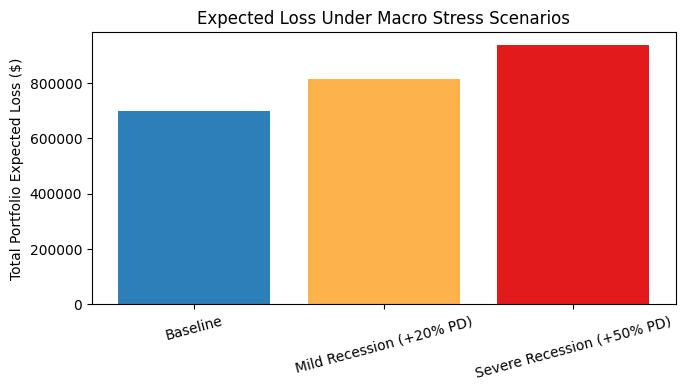

In [38]:
import numpy as np
import matplotlib.pyplot as plt

scenarios = {
    'Baseline': 1.0,
    'Mild Recession (+20% PD)': 1.2,
    'Severe Recession (+50% PD)': 1.5,
}

stress_results = []
for name, multiplier in scenarios.items():
    stressed_PD = np.clip(risk_df['PD'] * multiplier, 0, 1)
    stressed_EL = stressed_PD * risk_df['LGD'] * risk_df['EAD']
    stress_results.append({
        'scenario': name,
        'total_expected_loss': stressed_EL.sum(),
        'mean_PD': stressed_PD.mean(),
        'pct_above_50pct_PD': (stressed_PD > 0.5).mean() * 100
    })

stress_df = pd.DataFrame(stress_results)
print(stress_df)

plt.figure(figsize=(7,4))
plt.bar(stress_df['scenario'], stress_df['total_expected_loss'], color=['#2c7fb8','#feb24c','#e31a1c'])
plt.ylabel('Total Portfolio Expected Loss ($)')
plt.title('Expected Loss Under Macro Stress Scenarios')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('stress_test.png', dpi=150, bbox_inches='tight')
plt.show()

KS Statistic: 0.7576 at threshold 0.2024
Test AUC: 0.9424
Gini Coefficient: 0.8848


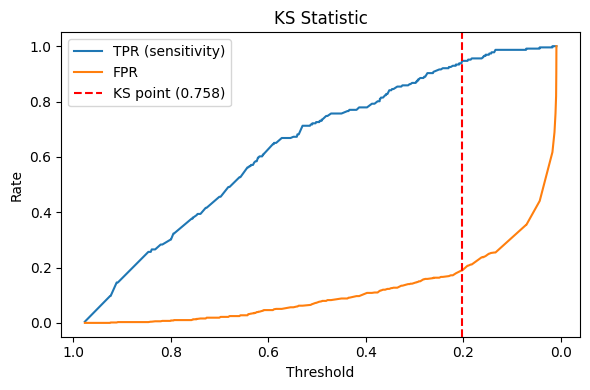

In [39]:
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np

# Recover actual test-set labels (matches idx_test from your conformal split)
y_test = y.iloc[idx_test].values

# PD is already computed from before: PD = base_model.predict_proba(X_test)[:, 1]

# --- KS Statistic ---
fpr, tpr, thresholds = roc_curve(y_test, PD)
ks_stat = np.max(tpr - fpr)
ks_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"KS Statistic: {ks_stat:.4f} at threshold {ks_threshold:.4f}")

# --- Gini Coefficient ---
test_auc = roc_auc_score(y_test, PD)
gini = 2 * test_auc - 1
print(f"Test AUC: {test_auc:.4f}")
print(f"Gini Coefficient: {gini:.4f}")

# --- KS plot (nice visual for the writeup) ---
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(thresholds, tpr, label='TPR (sensitivity)')
plt.plot(thresholds, fpr, label='FPR')
plt.axvline(ks_threshold, color='red', linestyle='--', label=f'KS point ({ks_stat:.3f})')
plt.gca().invert_xaxis()
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.title('KS Statistic')
plt.legend()
plt.tight_layout()
plt.savefig('ks_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Same train/test split as your model (idx_train, idx_test from the conformal split)
X_train_lr = X_selected[idx_train]
y_train_lr = y.iloc[idx_train].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lr)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_lr)

lr_PD = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_PD)
lr_gini = 2 * lr_auc - 1
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_PD)
lr_ks = np.max(tpr_lr - fpr_lr)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (baseline)', 'Random Forest (final)'],
    'AUC': [lr_auc, test_auc],
    'Gini': [lr_gini, gini],
    'KS': [lr_ks, ks_stat]
})
print(comparison_df)
comparison_df.to_csv('model_comparison.csv', index=False)

                            Model       AUC      Gini        KS
0  Logistic Regression (baseline)  0.943111  0.886222  0.755077
1           Random Forest (final)  0.942401  0.884802  0.757596
